## Supervisior Agent


In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

import os
from dotenv import load_dotenv
from langchain_aws import ChatBedrockConverse
load_dotenv()

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' 

model = ChatBedrockConverse(model= "us.anthropic.claude-sonnet-4-6")

In [2]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition, ToolNode
from langgraph.types import Command

from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langchain.agents import create_agent

from operator import add
from typing import TypedDict, Annotated, Literal

from langchain_tavily import TavilySearch
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

c:\Data\Codes\AgenticAITraining\Lanchain_LangGraph\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### Define Tools
- We define a search tool (duckduckgo) and a custom grammer checker. 
- In a real-world version, grammer like user Grammerly API 

In [4]:
duckduckgo_tool = DuckDuckGoSearchRun()

@tool
def grammer_checker_tool(text: Annotated[str, 'The text to review for grammar corrections']):
    '''Suggest grammar improvements to the given text.'''
    return f'Example Response: Review grammer for: {text}'

In [5]:
members = ['content_writer', 'proofreader']
options = members + ['FINISH']

class Router(TypedDict):
    """Worker to route to next agent.If nt worker needed , route to finish"""
    next: Literal[*options]

class State(MessagesState):
    next: str


- Router is used to parse the supervisior's structrued response.
- State tracks current message and which agent is next.

### Supervisior Agnet

In [ ]:
system_prompt = f"""
You are a supervisor managing workers: {members}.
Follow this order strictly:
1. If no content has been written yet → route to content_writer
2. If content_writer has responded but proofreader has NOT → route to proofreader
3. If proofreader has responded → route to FINISH
Never route to the same worker twice. When all work is done, respond with FINISH.
"""

def supervisior_node(state: State) -> Command[Literal[*members, "__end__"]]:
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model.with_structured_output(Router).invoke(messages)
    goto = response.get("next") if isinstance(response, dict) else response.next
    goto = END if goto == 'FINISH' else goto
    return Command(goto = goto, update = {'next': goto})


SUpervisor reads all the messages and decides who works next and returns control accordingly.
If the response is FINISH, the workflow ends

#### Worker agents

In [7]:
## Content Writer Agent
content_writer = create_agent(
    model, 
    tools = [duckduckgo_tool], 
    system_prompt="You are a content writer. Write high quality content based on user request."
)

def content_writer_node(state: State) -> Command[Literal["supervisor"]]:
    result = content_writer.invoke(state)
    return Command(
        update = {'messages': [
            HumanMessage(content=result['messages'][-1].content, name='content_writer')
        ]},
        goto = 'supervisor'
    )


The above node uses ReAct baasd reasoning with the search tool.
Sends the result back to the supervisor

In [8]:
## ProofReader Agent
from langchain.agents import create_agent
proofreader = create_agent(
    model,
    tools = [grammer_checker_tool], 
    system_prompt=" You are a proofreader. Review and correct grammar in the content provided."
)

def proofreader_node(state: State) -> Command[Literal["supervisor"]]:
    result = proofreader.invoke(state)
    return Command(
        update = {'messages': [HumanMessage(result['messages'][-1].content, name='proofreader')]},
        goto = 'supervisor'
    )

#### COnnecting and comipling the graph

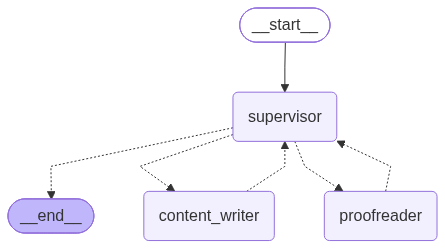

In [9]:
graph = StateGraph(State)
graph.add_node("supervisor", supervisior_node)
graph.add_node("content_writer", content_writer_node)
graph.add_node("proofreader", proofreader_node)
graph.add_edge(START, "supervisor")
app = graph.compile()
app

In [10]:
for s in app.stream(
    {'messages': [HumanMessage(content = 'Write an article on the befirs of AI in education', name = 'user')]},
    subgraphs=True
):
    print(s)

((), {'supervisor': {'next': 'content_writer'}})
((), {'content_writer': {'messages': [HumanMessage(content="# The Benefits of AI in Education: Transforming the Future of Learning\n\n---\n\n## Introduction\n\nArtificial Intelligence (AI) is no longer a concept confined to science fiction or Silicon Valley boardrooms. It has firmly planted its roots in one of the most critical sectors of human society — **education**. From kindergarten classrooms to university lecture halls, AI is quietly and powerfully reshaping how students learn, how teachers teach, and how institutions operate.\n\nAccording to the Consortium for School Networking, **97% of education leaders** see clear benefits in how AI can positively impact education. This overwhelming consensus signals not just a passing trend, but a fundamental transformation in the way knowledge is delivered and absorbed. As we move further into the digital age, understanding the benefits of AI in education is not just important — it is essenti

KeyboardInterrupt: 

Stuck in inf loop.